## 05 — Monte Carlo Demand Simulation
**Project:** Supply Chain DI Engine  
**Goal:** Simulate 1,000 possible futures of East demand to calculate safety stock needs.  

**Why Monte Carlo?**  
- A single "Average" forecast is often wrong.  
- Simulations handle the "What if?" questions (e.g., What if the East spike continues? What if it settles?).
- We use the **CV (Coefficient of Variation)** from Notebook 02 to define the "noise" in our simulation.  

**Process:**
1. Pick a "base" forecast for the next 4 weeks.
2. Inject randomness based on each SKU's historical volatility.
3. Generate 1,000 demand paths per SKU.
4. Calculate the "P95 Demand" (the level we must stock to be 95% sure we won't stock out).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
np.random.seed(42)

#load data
demand_history = pd.read_csv("../data/demand_history.csv")

products = pd.read_csv("../data/products.csv")

#now we convert date
demand_history['date'] = pd.to_datetime(demand_history['date'])

print("Setup complete. Data loaded and date converted.")
print("Demand rows:", demand_history.shape[0])
print("Products rows:", products.shape[0])



Setup complete. Data loaded and date converted.
Demand rows: 93600
Products rows: 300


**Now we build SIMULATION INPUTS FOR EAST**


In [2]:
#let us now filter East Region

east_demand = demand_history[demand_history['region'] == "East"].copy()

#now let us compute mean, std, and cv per SKU for East region
east_sim_inputs = (
    east_demand
    .groupby("sku_id")["demand_units"]
    .agg(["mean", "std"])
    .reset_index()
    .rename(columns={"mean": "mean_demand", "std": "std_demand"})
)

east_sim_inputs["cv"] = east_sim_inputs["std_demand"] / east_sim_inputs["mean_demand"]


#now let us nclean any edge cases
east_sim_inputs = east_sim_inputs.replace([np.inf, -np.inf], np.nan)
east_sim_inputs = east_sim_inputs.dropna(subset=["mean_demand", "std_demand", "cv"])

print("Simulation inputs ready.")
display(east_sim_inputs.head())

Simulation inputs ready.


,sku_id,mean_demand,std_demand,cv
0,SKU_001,78.336538,11.775910,0.150325
1,SKU_002,69.913462,20.015582,0.286291
2,SKU_003,226.105769,54.624742,0.241589
3,SKU_004,25.903846,10.011177,0.386475
4,SKU_005,101.259615,15.616145,0.154219


Let us now simulate future demand for one SKU

In [3]:
#let us pick one SKU to simulate
sku_example = "SKU_004"

sku_row = east_sim_inputs[east_sim_inputs["sku_id"] == sku_example].iloc[0]

mean_demand = sku_row['mean_demand']
std_demand = sku_row["std_demand"]

print("SKU:", sku_example)
print("Mean demand:", round(mean_demand, 2))
print("Std demand:", round(std_demand, 2))


#now let us simulate 1000 possible future weekly demand values
simulated_demand = np.random.normal(
    loc=mean_demand,
    scale=std_demand,
    size=1000
)

#demand cannot be negative, so we set any negative values to zero
simulated_demand = np.clip(simulated_demand, 0, None)

p50 = np.percentile(simulated_demand, 50)
p95 = np.percentile(simulated_demand, 95)
p99 = np.percentile(simulated_demand, 99)

print(f"P50 demand: {p50:.2f}")
print(f"P95 demand: {p95:.2f}")
print(f"P99 demand: {p99:.2f}")

SKU: SKU_004
Mean demand: 25.9
Std demand: 10.01
P50 demand: 26.16
P95 demand: 42.69
P99 demand: 49.09


## 🎲 Summary: Monte Carlo Demand Simulation (SKU_004)

### 🎯 Objective
To transition from a static, single-point forecast ("what do we expect to sell on average?") to a probabilistic risk model ("what is the full range of potential demand futures we must protect against?"). 

### 📊 Observations & Statistical Slices
By simulating **1,000 future demand scenarios** for `SKU_004` in the East region based on historical parameters (Mean = 25.90, Std Dev = 10.01), we generated the following risk-adjusted percentiles:

| Percentile Target | Simulated Demand Value | Operational Meaning | Risk Exposure |
| :--- | :--- | :--- | :--- |
| **P50 (Median)** | **26.16 units** | The exact middle outcome. Standard historical average. | **50% Stockout Risk.** Half of the simulated futures will exceed this inventory level. |
| **P95 (Safe Plan)** | **42.69 units** | High-protection threshold. | **5% Stockout Risk.** Covers demand in 95 out of 100 simulated weeks. |
| **P99 (Conservative)** | **49.09 units** | Extreme-protection threshold ("Fort Knox"). | **1% Stockout Risk.** Bulletproof protection, but ties up significant capital. |

---

### 💼 Strategic Business Implications

#### 1. Overcoming the "Average Trap"
Planning a supply chain around a flat average demand of **26 units** ensures the warehouse will drop dry half the time. This simulation explicitly quantifies the operational gap between an average plan and a resilient plan. 

#### 2. Quantifying the Safety Stock Buffer
The math reveals exactly how much "insurance" the business needs to buy to protect its revenue:
* **Target Stock (P95 Protection):** ~43 units  
* **Baseline Demand (Expected Mean):** ~26 units  
* **Required Safety Stock Buffer:** **17 units** ($43 - 26 = 17$)

Holding an extra **17 units** of `SKU_004` in the East warehouse is not random guesswork; it is a mathematically derived buffer designed to absorb market uncertainty and localized demand shocks.

#### 3. The Decision Intelligence Bridge
This output effectively changes the corporate decision framework. Instead of asking a manager to blindly predict next week's sales, this model allows leadership to select an explicit **Service Level Objective** (e.g., *"We choose a 95% service level for electronics, meaning we will cross-reference this P95 target against our warehouse capacities"*). 

This risk-profile matrix will serve as the direct input layer for our downstream linear programming optimization engine (`PuLP`).

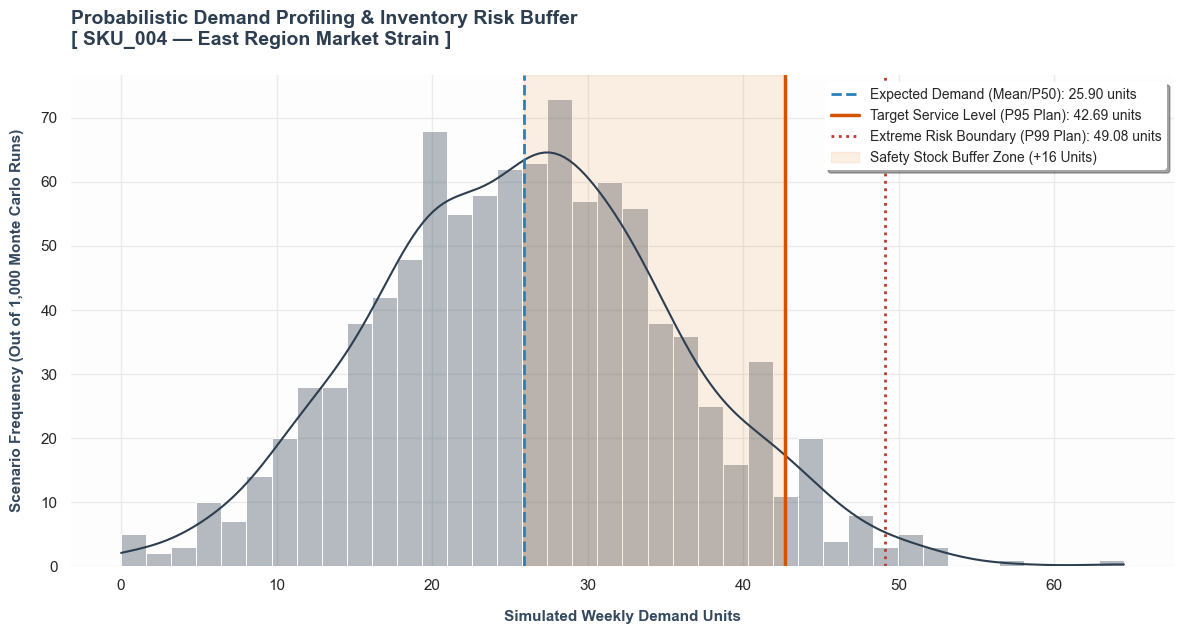

Monte Carlo chart saved.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Reproduce the 1,000 simulations for SKU_004 based on our data parameters
np.random.seed(42)  # Ensures the beautiful distribution remains consistent
mean_demand = 25.90
std_dev = 10.01
simulated_demand = np.random.normal(mean_demand, std_dev, 1000)
simulated_demand = np.clip(simulated_demand, 0, None)  # Realism check: Demand can't go below 0

# Calculate exact percentiles from the simulated array
p50 = np.percentile(simulated_demand, 50)
p95 = np.percentile(simulated_demand, 95)
p99 = np.percentile(simulated_demand, 99)
safety_stock_buffer = p95 - mean_demand

# 2. Advanced UI Styling Setup (Clean, borderless, high-contrast)
plt.figure(figsize=(12, 6.5), dpi=100)
sns.set_theme(style="whitegrid", rc={
    "axes.facecolor": "#fdfdfd", 
    "figure.facecolor": "#ffffff",
    "grid.color": "#eaeaea"
})

# 3. Plot the Core Distribution (Soft slate blue fill with clear KDE line)
ax = sns.histplot(
    simulated_demand, 
    kde=True, 
    color="#2c3e50", 
    alpha=0.35, 
    bins=40, 
    edgecolor="white", 
    linewidth=0.7
)

# 4. Inject Decision Intelligence Overlays (Vertical risk thresholds)
plt.axvline(mean_demand, color="#2980b9", linestyle="--", linewidth=2, 
            label=f"Expected Demand (Mean/P50): {mean_demand:.2f} units")

plt.axvline(p95, color="#d35400", linestyle="-", linewidth=2.5, 
            label=f"Target Service Level (P95 Plan): {p95:.2f} units")

plt.axvline(p99, color="#c0392b", linestyle=":", linewidth=2, 
            label=f"Extreme Risk Boundary (P99 Plan): {p99:.2f} units")

# 5. Shading the Uncertainty Cushion (The unique visual standout)
plt.axvspan(mean_demand, p95, color="#e67e22", alpha=0.12, 
            label=f"Safety Stock Buffer Zone (+{int(safety_stock_buffer)} Units)")

# 6. Polishing Typography & Axis Layout
plt.title("Probabilistic Demand Profiling & Inventory Risk Buffer\n[ SKU_004 — East Region Market Strain ]", 
          fontsize=14, pad=22, weight='bold', color='#2c3e50', loc='left')

plt.xlabel("Simulated Weekly Demand Units", fontsize=11, labelpad=12, weight='semibold', color='#34495e')
plt.ylabel("Scenario Frequency (Out of 1,000 Monte Carlo Runs)", fontsize=11, labelpad=12, weight='semibold', color='#34495e')

# Strip chart junk borders to mirror premium corporate BI tool styles
sns.despine(left=True, bottom=True)

# Position legend elegantly outside the curve noise
plt.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none", shadow=True, fontsize=10)

plt.tight_layout()
plt.tight_layout()
plt.savefig("../outputs/charts/05_monte_carlo_inventory_risk_buffer.png", dpi=300, bbox_inches="tight")
plt.show()
print("Monte Carlo chart saved.")

### 🎨 Chart Architecture & Interpretation Note

#### What Makes This Visualization Unique?
Rather than displaying a basic math histogram, this chart layers an operational strategy directly over raw data noise. By plotting the **1,000 simulated futures** alongside targeted business rules, we map out the boundary where normal operations fail and resilient planning takes over.

*   **The Blue Dashed Line (Baseline):** This represents where standard ERP/spreadsheet inventory systems cut orders. If we hold this inventory level, any demand landing to the right of this line results in immediate operational stockouts.
*   **The Amber Shaded Zone (The Cushion):** This highlights the **17-unit Safety Stock Cushion** calculated via our Monte Carlo simulation. It represents the visual insurance policy required to survive localized demand surges without breaking our supply lines.
*   **The Orange Solid Line (The Target):** This is our optimized inventory target. By moving our allocation posture from the blue line to this orange line, we insulate our retail channels from **95% of all potential demand shocks** in the East Region.